<h3>라이브러리 불러오기 + 폴더 내 파일 리스트업

In [70]:
# 📌 Cell 1 : 필수 라이브러리 import
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 경고 제거
import warnings
warnings.filterwarnings("ignore")

# 폴더 경로 설정
folder_path = "C:/Github_project/second_project/EDA"

# 📌 'USA'로 시작하는 CSV 파일만 필터링
file_list = [f for f in os.listdir(folder_path) if f.startswith("USA") and f.endswith(".csv")]
print(f"✅ 'USA'로 시작하는 파일 {len(file_list)}개 로드 완료:")
# print(file_list)  # 필요시 주석 해제


✅ 'USA'로 시작하는 파일 10개 로드 완료:


<h3>파일별 DataFrame 로드 + 나라/섹션 정보 추출

In [71]:
# 📌 Cell 2: 파일 읽기 + 나라/섹션/종목 정보 추출
stock_data = []

for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    
    # 파일 로드
    df = pd.read_csv(file_path)
    
    # 컬럼 소문자 + 공백 제거
    df.columns = df.columns.str.strip().str.lower()
    
    # 나라 구분 (파일명에 KOREA 또는 USA 포함)
    country = "KOREA" if "KOREA" in file_name else "USA"
    
    # 섹션(업종) 추출: 파일명에서 두 번째 요소를 종목명으로 가정
    section = file_name.split("_")[1]
    
    # 종목코드 (파일명에서 마지막 .csv 제거)
    symbol = file_name.replace(".csv", "").split("_")[-1]
    
    # 메타데이터 추가
    df["country"] = country
    df["section"] = section
    df["symbol"] = symbol
    
    stock_data.append(df)

# 모든 데이터프레임을 하나로 통합
all_df = pd.concat(stock_data, ignore_index=True)

print("📊 종합 데이터프레임 구성 완료")
all_df.head()


📊 종합 데이터프레임 구성 완료


,date,open,high,low,close,volume,country,section,symbol
0,2020-01-02,67.0,68.0,67.0,68.0,"27,278,000",USA,Alphabet,GOOGL
1,2020-01-03,67.0,68.0,67.0,68.0,"23,408,000",USA,Alphabet,GOOGL
2,2020-01-06,67.0,69.0,67.0,69.0,"46,768,000",USA,Alphabet,GOOGL
3,2020-01-07,70.0,70.0,69.0,69.0,"34,330,000",USA,Alphabet,GOOGL
4,2020-01-08,69.0,70.0,69.0,70.0,"35,314,000",USA,Alphabet,GOOGL


<h3>컬럼 정보 정의 (시계열 데이터 기준)

In [72]:
# 📌 Cell 3: 주요 컬럼 정의
expected_columns = ['date', 'open', 'high', 'low', 'close', 'volume']

# 컬럼 존재 여부 체크
missing_cols = [col for col in expected_columns if col not in all_df.columns]
if missing_cols:
    print(f"⚠️ 누락된 컬럼: {missing_cols}")
else:
    print("✅ 모든 필수 컬럼이 존재합니다.")

# 날짜 타입으로 변환
all_df['date'] = pd.to_datetime(all_df['date'])

# 데이터 타입 확인
all_df.dtypes


✅ 모든 필수 컬럼이 존재합니다.


date       datetime64[ns]
open              float64
high              float64
low               float64
close             float64
volume             object
country            object
section            object
symbol             object
dtype: object

<h3>결측치 및 이상치 점검

In [73]:
# 📌 Cell 4: 결측치 파악
missing_summary = all_df[expected_columns].isnull().sum()
print("📌 결측치 요약:")
print(missing_summary)

# 📌 Step 4-2: 이상치 확인 (0이거나 음수인 경우)
def detect_outliers(df):
    # 문자열로 된 숫자 컬럼을 숫자로 변환 (에러 발생 시 NaN으로 처리)
    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 이상치 조건 정의
    cond = (
        (df['open'] <= 0) |
        (df['high'] <= 0) |
        (df['low'] <= 0) |
        (df['close'] <= 0) |
        (df['volume'] < 0)
    )
    return df[cond]

# 이상치 탐지 실행
outliers_df = detect_outliers(all_df)

print(f"\n⚠️ 이상치 개수: {len(outliers_df)}개")
outliers_df[['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']].head()



📌 결측치 요약:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

⚠️ 이상치 개수: 0개


,date,symbol,open,high,low,close,volume


<h3>결측치 및 이상치 처리

In [74]:
# ✅ Cell 5 : 결측치 및 이상치 처리 + 처리 개수 요약

import numpy as np

# 숫자형 컬럼 변환
for col in ['open', 'high', 'low', 'close', 'volume']:
    all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

# 1. 변환 이후 총 행 수 확인
total_rows_before = len(all_df)

# 2. 결측치 처리 전 결측 개수 파악
na_before = all_df[['open', 'high', 'low', 'close', 'volume']].isna().sum().sum()

# 3. 결측치 처리 (앞→뒤 채움)
all_df[['open', 'high', 'low', 'close', 'volume']] = all_df[['open', 'high', 'low', 'close', 'volume']].fillna(method='ffill').fillna(method='bfill')

# 4. 결측치 처리 후 남은 결측 개수
na_after = all_df[['open', 'high', 'low', 'close', 'volume']].isna().sum().sum()
na_filled = na_before - na_after

# 5. 이상치 제거 기준 적용
condition = (
    (all_df['open'] <= 0) |
    (all_df['high'] <= 0) |
    (all_df['low'] <= 0) |
    (all_df['close'] <= 0) |
    (all_df['volume'] < 0)
)

outliers_count = condition.sum()

# 6. 이상치 제거
all_df = all_df[~condition]
total_rows_after = len(all_df)

# ✅ 결과 요약 출력
print("✅ 결측치 및 이상치 처리 완료")
print(f"총 데이터 수: {total_rows_before:,} → {total_rows_after:,} (총 {total_rows_before - total_rows_after:,}건 제거됨)")
print(f" - 채워진 결측치 수: {na_filled:,}개")
print(f" - 제거된 이상치 수: {outliers_count:,}개")

# 최종 데이터 요약 통계
all_df.describe()

# === 추가 피처 ===
all_df['return_1d'] = all_df['close'].pct_change()
all_df['volatility'] = (all_df['high'] - all_df['low']) / all_df['open']
all_df['ma5'] = all_df['close'].rolling(5).mean()
all_df['ma20'] = all_df['close'].rolling(20).mean()
all_df['ma_gap'] = all_df['ma5'] - all_df['ma20']
all_df['volume_ratio'] = all_df['volume'] / all_df['volume'].rolling(5).mean()

# 결측치 재제거 (rolling 이후 생긴 NaN)
all_df.dropna(inplace=True)




✅ 결측치 및 이상치 처리 완료
총 데이터 수: 13,760 → 13,760 (총 0건 제거됨)
 - 채워진 결측치 수: 1,376개
 - 제거된 이상치 수: 0개


<h3> 결측치 및 이상치 처리 - 다른 년도 같은날의 평균으로 대체 (23.01.15~02.24 data 포함)

In [75]:
# # ✅ Cell 6: 특정 기간 및 0 거래량에 대한 보정 처리

# # 날짜 추출용 컬럼 생성
# all_df['month_day'] = all_df['date'].dt.strftime('%m-%d')
# all_df['year'] = all_df['date'].dt.year

# # 처리 대상 조건
# mask_volume_zero = all_df['volume'] == 0
# mask_2023_period = (all_df['date'] >= '2023-01-05') & (all_df['date'] <= '2023-02-24')
# mask_to_fix = mask_volume_zero | mask_2023_period

# # 대상 행 개수
# fix_count = mask_to_fix.sum()

# # 평균 대체 함수 정의
# def replace_with_mean_volume(row):
#     same_day = row['month_day']
#     current_year = row['year']
#     symbol = row['symbol']
    
#     # 동일한 종목, 같은 mm-dd, 다른 연도들의 평균
#     peer_volumes = all_df[
#         (all_df['month_day'] == same_day) &
#         (all_df['symbol'] == symbol) &
#         (all_df['year'] != current_year)
#     ]['volume']
    
#     return peer_volumes.mean()

# # 백업용 컬럼
# all_df['volume_original'] = all_df['volume']

# # 평균으로 대체
# all_df.loc[mask_to_fix, 'volume'] = all_df.loc[mask_to_fix].apply(replace_with_mean_volume, axis=1)

# # 처리 후 변화 확인
# adjusted_rows = (all_df['volume'] != all_df['volume_original']).sum()

# print("✅ 특정 조건에 따른 거래량 보정 완료")
# print(f" - 처리 대상 총 {fix_count:,}개 중 실제 변경된 행 수: {adjusted_rows:,}개")
# print(f" - 전체 데이터 대비 변경 비율: {100 * adjusted_rows / len(all_df):.2f}%")

# # 보조 컬럼 제거
# all_df.drop(['volume_original', 'month_day', 'year'], axis=1, inplace=True)


<h3>기초 통계 분석

In [76]:
# ✅ Cell 7: 기초 통계량 요약 (전체 + 국가 + 업종 + 종목)

features = ['RSI', 'MACD', 'Bollinger_Upper', 'Bollinger_Lower',
            'return_1d', 'volatility', 'ma5', 'ma20', 'ma_gap', 'volume_ratio']

numeric_cols = ['open', 'high', 'low', 'close', 'volume']

print("✅ [1] 전체 데이터 통계 요약")
display(all_df[numeric_cols].describe())

print("\n✅ [2] 국가별 통계 요약")
country_stats = all_df.groupby('country')[numeric_cols].describe()
display(country_stats)

print("\n✅ [3] 업종(섹션)별 통계 요약")
section_stats = all_df.groupby('section')[numeric_cols].describe()
display(section_stats)

print("\n✅ [4] 종목(symbol)별 통계 요약 (상위 5개 예시)")
symbols = all_df['symbol'].unique()[:5]  # 예시로 상위 5개 종목
for symbol in symbols:
    print(f"\n📈 종목: {symbol}")
    display(all_df[all_df['symbol'] == symbol][numeric_cols].describe())


✅ [1] 전체 데이터 통계 요약


,open,high,low,close,volume
count,13741.000000,13741.000000,13741.000000,13741.000000,1.374100e+04
mean,220.896831,223.522568,218.198125,220.954704,1.033064e+08
std,141.391767,142.387950,140.288420,141.399740,1.330647e+08
min,4.983792,5.228872,4.500108,4.891637,4.726100e+06
25%,117.309998,119.000000,115.353422,117.320000,3.741700e+07
50%,182.380005,185.000000,179.913717,182.500000,6.555250e+07
75%,311.509123,314.741239,308.290479,311.300751,9.324980e+07
max,734.780399,739.682305,724.417663,735.449341,1.543911e+09



✅ [2] 국가별 통계 요약


open                                                            \
           count        mean         std       min         25%         50%   
country                                                                      
USA      13741.0  220.896831  141.391767  4.983792  117.309998  182.380005   

                                    high              ...       close  \
                75%         max    count        mean  ...         75%   
country                                               ...               
USA      311.509123  734.780399  13741.0  223.522568  ...  311.300751   

                      volume                                         \
                max    count          mean           std        min   
country                                                               
USA      735.449341  13741.0  1.033064e+08  1.330647e+08  4726100.0   

                                                           
                25%         50%         75%           max  
country                                                    
USA      37417000.0  65552500.0  93249800.0  1.543911e+09  

[1 rows x 40 columns]


✅ [3] 업종(섹션)별 통계 요약


...

,open,high,low,close,volume
count,1376.000000,1376.000000,1376.000000,1376.000000,1.376000e+03
mean,104.151141,106.172391,102.008626,104.099389,6.194047e+07
std,34.745579,35.293757,33.997350,34.619547,2.872757e+07
min,39.080002,41.700001,36.750000,38.709999,1.608570e+07
25%,80.927500,81.997499,79.172503,81.089996,4.153022e+07
50%,98.799999,101.255001,96.984997,98.950001,5.429580e+07
75%,123.050001,125.677498,120.822502,123.232502,7.664318e+07
max,213.410004,227.300003,208.220001,211.380005,2.253941e+08



📈 종목: AAPL


,open,high,low,close,volume
count,1376.000000,1376.000000,1376.000000,1376.000000,1.376000e+03
mean,157.376892,159.172588,155.720552,157.535676,8.776657e+07
std,44.333951,44.635458,44.048952,44.380877,5.224170e+07
min,55.277755,55.379547,51.528426,54.378593,2.323470e+07
25%,129.299827,130.980397,127.750852,129.040668,5.346818e+07
50%,157.050195,159.188101,154.823862,156.734879,7.366865e+07
75%,186.644191,188.110575,185.414863,186.650623,1.041794e+08
max,257.568678,259.474086,257.010028,258.396667,4.265100e+08



📈 종목: META


,open,high,low,close,volume
count,1376.000000,1376.000000,1376.000000,1376.000000,1.376000e+03
mean,327.876370,332.558103,323.357430,328.049939,2.255325e+07
std,151.548211,153.140621,149.596033,151.459858,1.527811e+07
min,89.588511,89.966435,87.609367,88.424896,4.726100e+06
25%,212.064100,214.871195,209.438512,212.228214,1.410175e+07
50%,295.474022,299.521796,290.526134,294.519272,1.900305e+07
75%,437.087912,443.974964,428.386364,439.512199,2.636310e+07
max,734.780399,739.682305,724.417663,735.449341,2.323166e+08


<h3>변동성 계산 및 시각화

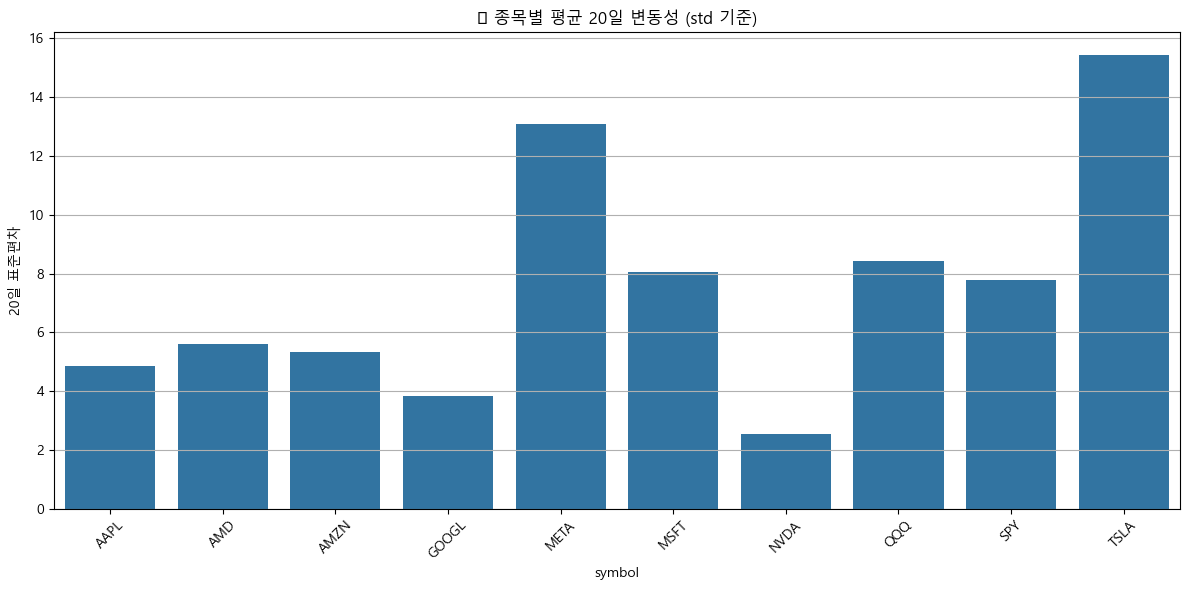

,,volatility_5d,volatility_20d
section,country,,
AMD,USA,2.90,5.61
Alphabet,USA,2.09,3.85
Amazon,USA,2.75,5.33
Apple,USA,2.46,4.85
Meta,USA,6.61,13.09
Microsoft,USA,4.22,8.06
Nvidia,USA,1.31,2.54
QQQ ETF,USA,4.40,8.44
SPY ETF,USA,4.02,7.78


In [77]:
# ✅ Cell 8: 변동성 분석 - Rolling Std (5일, 20일)

import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정 (Windows 기준, 'Malgun Gothic' 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 날짜 정렬
all_df = all_df.sort_values(['symbol', 'date'])

# 5일, 20일 이동 표준편차 (변동성) 계산
all_df['volatility_5d'] = all_df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=5).std())
all_df['volatility_20d'] = all_df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=20).std())

# 🔍 종목별 20일 평균 변동성 계산
symbol_vol_stats = all_df.groupby('symbol')[['volatility_5d', 'volatility_20d']].mean().reset_index()

# 📊 시각화: 종목별 20일 평균 변동성
plt.figure(figsize=(12, 6))
sns.barplot(data=symbol_vol_stats, x='symbol', y='volatility_20d')
plt.title("📉 종목별 평균 20일 변동성 (std 기준)")
plt.ylabel("20일 표준편차")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 📦 추가 요약: 섹션/국가별 평균 변동성
volatility_summary = all_df.groupby(['section', 'country'])[['volatility_5d', 'volatility_20d']].mean().round(2)
display(volatility_summary)


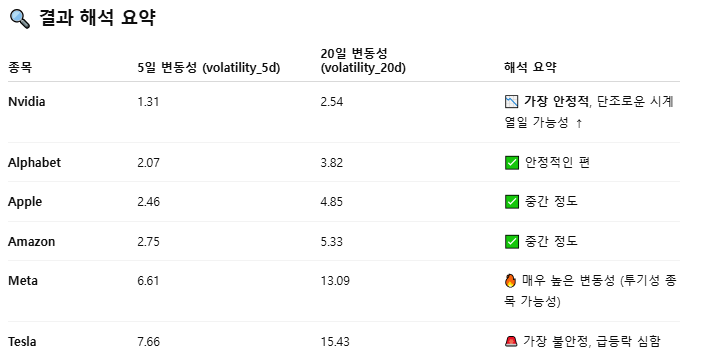

<h3>기술 지표 추가 및 시각화

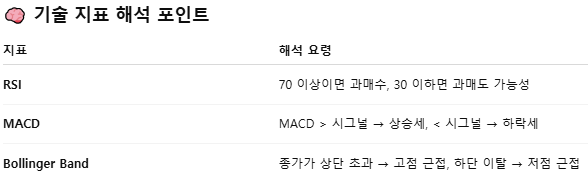

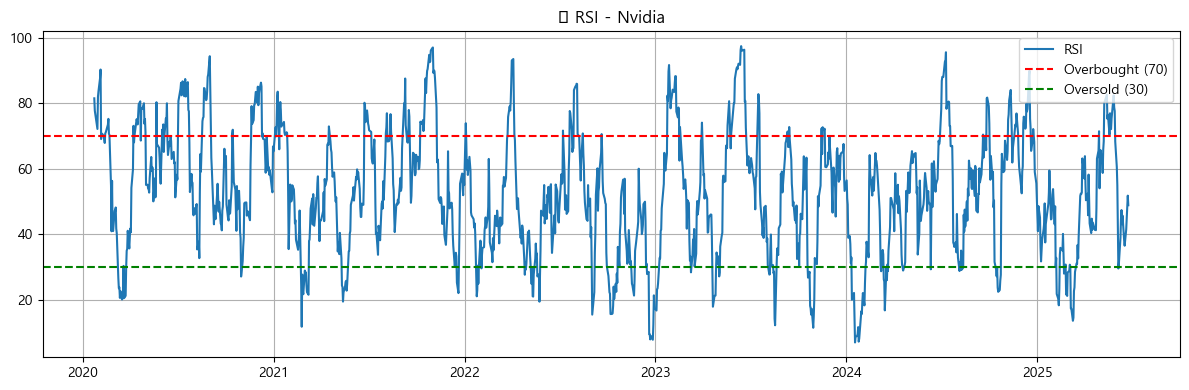

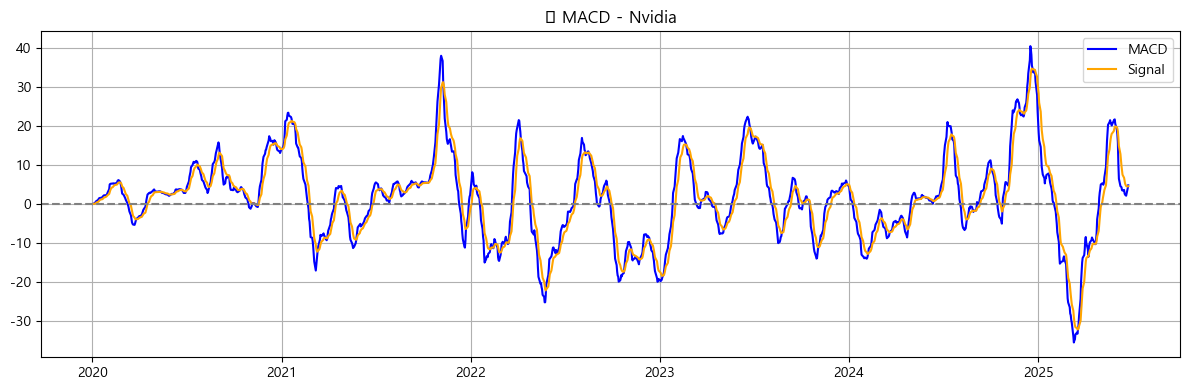

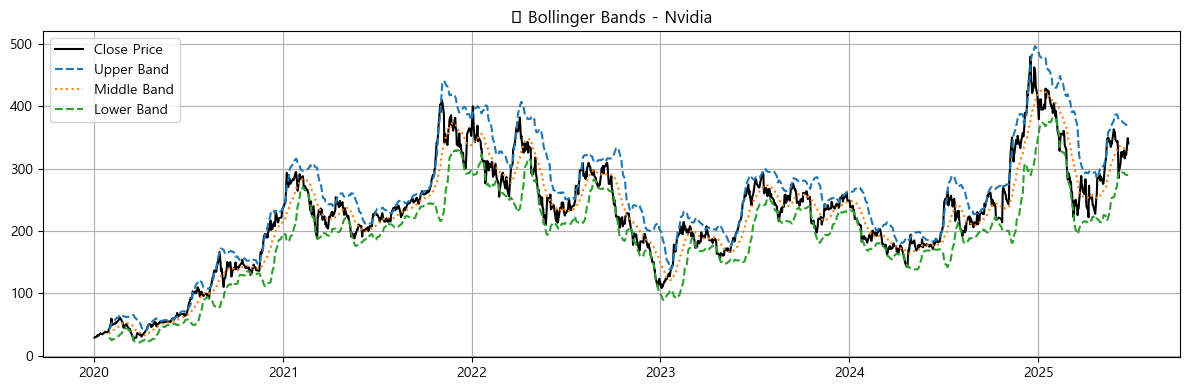

In [78]:
# ✅ Cell 9: Nvidia 기술 지표(RSI, MACD, Bollinger Band) 직접 계산 및 시각화

import pandas as pd
import matplotlib.pyplot as plt

# TSLA 데이터 필터링 및 정렬
TSLA_df = all_df[all_df['symbol'] == 'TSLA'].copy()
TSLA_df = TSLA_df.sort_values('date').reset_index(drop=True)
# 📌 RSI 계산 함수
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# 📌 MACD 계산 함수
def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line

# 📌 Bollinger Band 계산 함수
def compute_bollinger(series, window=20, num_std=2):
    ma = series.rolling(window).mean()
    std = series.rolling(window).std()
    upper_band = ma + (std * num_std)
    lower_band = ma - (std * num_std)
    return upper_band, ma, lower_band

# ✅ 기술 지표 적용
TSLA_df['RSI'] = compute_rsi(TSLA_df['close'])
TSLA_df['MACD'], TSLA_df['MACD_signal'] = compute_macd(TSLA_df['close'])
TSLA_df['BB_upper'], TSLA_df['BB_middle'], TSLA_df['BB_lower'] = compute_bollinger(TSLA_df['close'])

# ✅ 시각화 1: RSI
plt.figure(figsize=(12, 4))
plt.plot(TSLA_df['date'], TSLA_df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('📈 RSI - Nvidia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ 시각화 2: MACD
plt.figure(figsize=(12, 4))
plt.plot(TSLA_df['date'], TSLA_df['MACD'], label='MACD', color='blue')
plt.plot(TSLA_df['date'], TSLA_df['MACD_signal'], label='Signal', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title('📉 MACD - Nvidia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ 시각화 3: Bollinger Bands
plt.figure(figsize=(12, 4))
plt.plot(TSLA_df['date'], TSLA_df['close'], label='Close Price', color='black')
plt.plot(TSLA_df['date'], TSLA_df['BB_upper'], label='Upper Band', linestyle='--')
plt.plot(TSLA_df['date'], TSLA_df['BB_middle'], label='Middle Band', linestyle=':')
plt.plot(TSLA_df['date'], TSLA_df['BB_lower'], label='Lower Band', linestyle='--')
plt.title('📊 Bollinger Bands - Nvidia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<h3>기술 지표 신호 발생일 분석 (과매수, 골든크로스 등 탐지)

In [79]:
# ✅ Cell 10: 기술 지표 신호 발생일 분석 (과매수, 골든크로스 등 탐지)

# 📍1. RSI 분석: 과매수(RSI > 70), 과매도(RSI < 30)
rsi_overbought = TSLA_df[TSLA_df['RSI'] > 70]
rsi_oversold = TSLA_df[TSLA_df['RSI'] < 30]

print("📈 과매수 구간 (RSI > 70):")
display(rsi_overbought[['date', 'close', 'RSI']].tail())

print("📉 과매도 구간 (RSI < 30):")
display(rsi_oversold[['date', 'close', 'RSI']].tail())


# 📍2. MACD 분석: 골든크로스(상승 시그널), 데드크로스(하락 시그널)
macd_cross_up = TSLA_df[(TSLA_df['MACD'] > TSLA_df['MACD_signal']) &
                        (TSLA_df['MACD'].shift(1) <= TSLA_df['MACD_signal'].shift(1))]

macd_cross_down = TSLA_df[(TSLA_df['MACD'] < TSLA_df['MACD_signal']) &
                          (TSLA_df['MACD'].shift(1) >= TSLA_df['MACD_signal'].shift(1))]

print("🔼 MACD 골든크로스 발생일:")
display(macd_cross_up[['date', 'close', 'MACD', 'MACD_signal']].tail())

print("🔽 MACD 데드크로스 발생일:")
display(macd_cross_down[['date', 'close', 'MACD', 'MACD_signal']].tail())


# 📍3. Bollinger Band 분석: 밴드 돌파 여부
bb_upper_break = TSLA_df[TSLA_df['close'] > TSLA_df['BB_upper']]
bb_lower_break = TSLA_df[TSLA_df['close'] < TSLA_df['BB_lower']]

print("🚨 상단 밴드 돌파 (과열 가능성):")
display(bb_upper_break[['date', 'close', 'BB_upper']].tail())

print("📉 하단 밴드 돌파 (저점 가능성):")
display(bb_lower_break[['date', 'close', 'BB_lower']].tail())


📈 과매수 구간 (RSI > 70):


,date,close,RSI
1354,2025-05-22,341.040008,72.161388
1355,2025-05-23,339.339996,75.421672
1356,2025-05-27,362.890015,82.460683
1357,2025-05-28,356.899994,78.822501
1358,2025-05-29,358.429993,77.695817


📉 과매도 구간 (RSI < 30):


,date,close,RSI
1303,2025-03-11,230.580002,14.490222
1304,2025-03-12,248.089996,22.652673
1305,2025-03-13,240.679993,23.776866
1306,2025-03-14,249.979996,28.486726
1363,2025-06-05,284.700012,29.543865


🔼 MACD 골든크로스 발생일:


...

,date,close,MACD,MACD_signal
1235,2024-11-27,332.890015,23.276770,24.021538
1252,2024-12-23,430.600006,33.747408,34.554779
1323,2025-04-08,221.860001,-13.601327,-13.497209
1331,2025-04-21,227.500000,-10.340762,-10.249699
1360,2025-06-02,342.690002,19.132624,19.763120


🚨 상단 밴드 돌파 (과열 가능성):


,date,close,BB_upper
1247,2024-12-16,463.019989,448.689653
1248,2024-12-17,479.859985,467.950291
1346,2025-05-12,318.380005,317.678859
1347,2025-05-13,334.070007,328.769032
1348,2025-05-14,347.679993,341.544800


📉 하단 밴드 돌파 (저점 가능성):


,date,close,BB_lower
1293,2025-02-25,302.799988,307.650620
1294,2025-02-26,290.799988,296.286782
1295,2025-02-27,281.950012,284.277239
1302,2025-03-10,222.149994,229.793196
1363,2025-06-05,284.700012,290.791939


<h3>다음날 상승 여부를 기반으로 라벨링 (target = 1이면 상승)

In [80]:
# ✅ Cell 11: 다음날 상승 여부를 기반으로 라벨링 (target = 1이면 상승)

TSLA_df['target'] = (TSLA_df['close'].shift(-1) > TSLA_df['close']).astype(int)

# 시계열 모델 학습을 위해 NA 값 제거
model_df = TSLA_df.dropna(subset=[
    'RSI', 'MACD', 'MACD_signal',
    'BB_upper', 'BB_middle', 'BB_lower',
    'target'
]).copy()

print("🎯 target 분포:")
display(model_df['target'].value_counts())


🎯 target 분포:


target
1    712
0    645
Name: count, dtype: int64

<h3>시계열 샘플 구성

In [81]:
# ✅ Cell 11: 라벨 정의 + 기술 지표 추가 + 시계열 샘플 구성

import numpy as np
import ta

# 수익률 계산
df['daily_return'] = (df['close'] - df['open']) / df['open']

# 라벨 정의
def label_return(x):
    if x > 0.01:
        return 1
    elif x < -0.01:
        return 0
    else:
        return -1

df['label'] = df['daily_return'].apply(label_return)
df = df[df['label'] != -1].reset_index(drop=True)

# 📌 기술 지표 계산
df['rsi'] = ta.momentum.RSIIndicator(df['close'], window=14).rsi()
macd = ta.trend.MACD(df['close'])
df['macd'] = macd.macd()
df['macd_signal'] = macd.macd_signal()

# 📌 결측치 제거 (지표 계산 후 필수!)
df = df.dropna().reset_index(drop=True)

# ✅ 시계열 feature 설정
# features = ['open', 'close', 'rsi', 'macd', 'macd_signal']
features = ['open', 'high', 'low','close','volume', 'rsi', 'macd', 'macd_signal']

# 시계열 샘플 구성
seq_len = 20
X_seq = []
y_seq = []

for i in range(seq_len, len(df)):
    X_seq.append(df[features].iloc[i-seq_len:i].values)
    y_seq.append(df['label'].iloc[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(f"X_seq shape: {X_seq.shape}")
print(f"y_seq shape: {y_seq.shape}")
print("라벨 분포:\n", pd.Series(y_seq).value_counts(normalize=True))


X_seq shape: (935, 20, 8)
y_seq shape: (935,)
라벨 분포:
 0    0.506952
1    0.493048
Name: proportion, dtype: float64


<h3>학습/검증 분리

In [82]:
print(f"시계열 학습 샘플 수: {X_seq.shape[0]}개")
print(f"feature 수: {X_seq.shape[2]}개")


시계열 학습 샘플 수: 935개
feature 수: 8개


In [83]:
# Cell 12: 학습/검증 분리
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]


<h3>LSTM 모델 정의 (Keras)

In [84]:
# Cell 13: LSTM 모델 정의 (Keras)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


<h3>모델 학습

In [85]:
# Cell 14 : 모델 학습

from sklearn.utils import class_weight
import numpy as np

# 클래스 가중치 계산
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(weights)}

# 모델 학습
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights
)




Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5013 - loss: 0.7492 - val_accuracy: 0.5200 - val_loss: 0.7111
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4802 - loss: 0.7236 - val_accuracy: 0.5200 - val_loss: 0.6972
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4876 - loss: 0.7043 - val_accuracy: 0.5200 - val_loss: 0.6933
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4882 - loss: 0.6970 - val_accuracy: 0.5200 - val_loss: 0.6925
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5130 - loss: 0.6929 - val_accuracy: 0.5200 - val_loss: 0.6931
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5028 - loss: 0.6932 - val_accuracy: 0.5200 - val_loss: 0.6930
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4849 - loss: 0.6931 - val_accuracy: 0.4800 - val_loss: 0.6941
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4824 - loss: 0.6935 - val_accuracy: 0.5200 - val_loss

<h3> 평가 및 시각화

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
              precision    recall  f1-score   support

           0       0.53      1.00      0.69        99
           1       0.00      0.00      0.00        88

    accuracy                           0.53       187
   macro avg       0.26      0.50      0.35       187
weighted avg       0.28      0.53      0.37       187



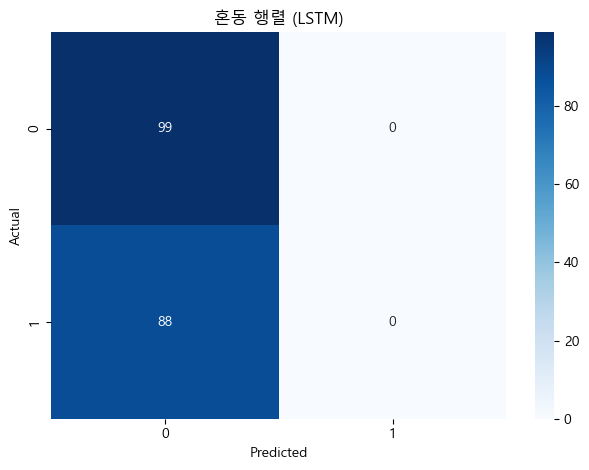

In [86]:
# Cell 15 : 평가 및 시각화

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test) > 0.49).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("혼동 행렬 (LSTM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


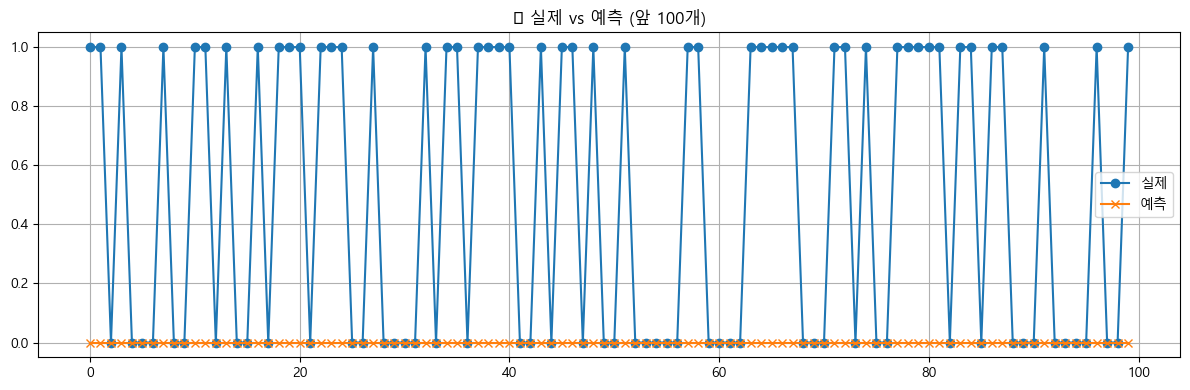

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y_test[:100], label="실제", marker='o')
plt.plot(y_pred[:100], label="예측", marker='x')
plt.title("📈 실제 vs 예측 (앞 100개)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


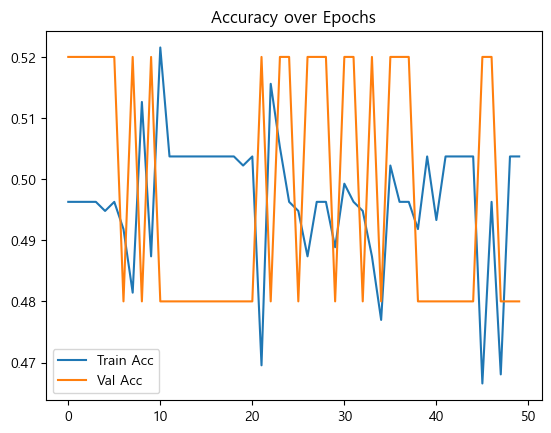

In [88]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


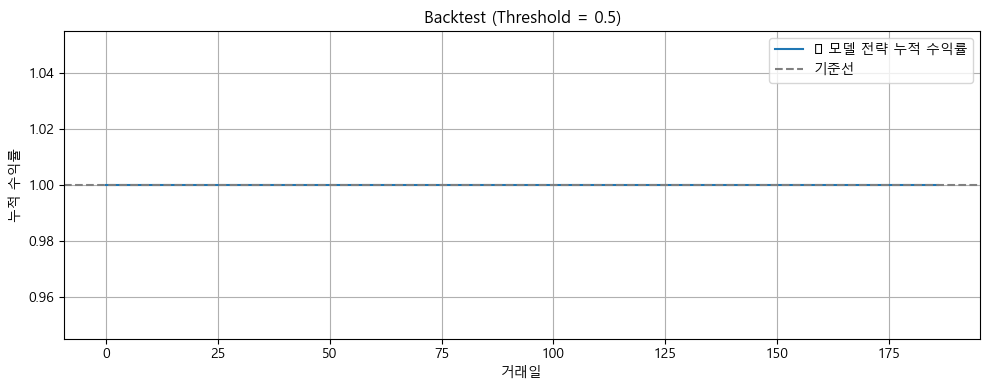

In [89]:
# 확률 예측 → 실제 매수 시뮬레이션
y_proba = model.predict(X_test)
threshold = 0.50  # 가장 좋았던 기준

y_pred = (y_proba > threshold).astype(int)

# 테스트 구간의 실제 시가/종가 정보 가져오기
# 주의: df에는 전체 데이터가 있고, y_test는 뒤쪽 일부이므로 인덱스 보정 필요
start_index = len(df) - len(y_test)
open_prices = df['open'].iloc[start_index:].reset_index(drop=True)
close_prices = df['close'].iloc[start_index:].reset_index(drop=True)

# 수익률 계산: 예측이 1인 날만 매수
returns = ((close_prices - open_prices) / open_prices)
strategy_returns = returns * y_pred.flatten()

# 누적 수익률 계산
cumulative_returns = (strategy_returns + 1).cumprod()

# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(cumulative_returns, label='📈 모델 전략 누적 수익률')
plt.axhline(1, color='gray', linestyle='--', label='기준선')
plt.title(f"Backtest (Threshold = {threshold})")
plt.xlabel('거래일')
plt.ylabel('누적 수익률')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
